# 🤙 Bangla Sign Language Recognition
### Digits (০–৯) + Alphabets (অ–য) — 47 classes
**Architecture**: MobileNetV2 Transfer Learning (ImageNet → BSL)

**Dataset structure expected:**
```
dataset/
├── Bangla Sign Language Dataset - Sign Digits/
│   └── User XX (Gender, Age)/
│       └── Sign N/
│           └── Input Images/
│               └── Sign N - Sample (k).jpg
└── Bangla Sign Language Dataset - Sign Alphabets/
    └── User XX - Gender, Age/
        └── sign NN/
            └── Input Images - sign NN/
                └── Sign NN - Sample (k).jpg
```

In [2]:
# Uncomment to install on first run
#%pip install tensorflow pillow numpy matplotlib scikit-learn seaborn

In [3]:
import os, re, glob, shutil, json, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print(f'TF {tf.__version__} | GPU: {bool(tf.config.list_physical_devices("GPU"))}')


TF 2.15.0 | GPU: False


## ⚙️ Config

In [11]:
# ── Paths ───────────────────────────────────────────────────────────────
DIGIT_RAW   = '../dataset/Bangla Sign Language Dataset - Sign Digits'
ALPHA_RAW   = '../dataset/Bangla Sign Language Dataset - Sign Alphabets'
PROCESSED   = './processed_dataset'
LABELS_JSON = '../backend/labels.json'

# ── Model ───────────────────────────────────────────────────────────────
IMG_SIZE        = (96, 96)
BATCH_SIZE      = 8
EPOCHS_FROZEN   = 5
EPOCHS_FINETUNE = 5
VAL_SPLIT       = 0.20
SEED            = 42

# 10 digits  (digit_0 … digit_9)
# 37 alphabets (alpha_00 … alpha_36)
NUM_CLASSES = 47

MODEL_OUT   = './bangla_sign_model.h5'
CI_OUT      = './class_indices.json'

# ── Label map ───────────────────────────────────────────────────────────
with open(LABELS_JSON, encoding='utf-8') as f:
    LABEL_MAP_RAW = json.load(f)

# Flat dict: folder_name → display info
LABEL_MAP = {**LABEL_MAP_RAW['digits'], **LABEL_MAP_RAW['alphabets']}
print(f'Label map loaded: {len(LABEL_MAP)} classes')

Label map loaded: 47 classes


## 📂 Step 1: Flatten Both Datasets
Combines both raw datasets into a single `processed_dataset/` with subfolders `digit_0`…`digit_9` and `alpha_00`…`alpha_36`.

In [12]:
def flatten_digit_dataset(raw_path, out_path, val_split=0.2, seed=42):
    """Flatten: .../Sign N/Input Images/Sign N - Sample (k).jpg → digit_N/"""
    random.seed(seed)
    raw = Path(raw_path)
    stats = {}
    for sign_idx in range(10):
        class_name = f'digit_{sign_idx}'
        for split in ['train', 'val']:
            Path(f'{out_path}/{split}/{class_name}').mkdir(parents=True, exist_ok=True)

        # Glob across all users
        imgs = list(raw.rglob(f'Sign {sign_idx} - Sample*.jpg'))
        imgs += list(raw.rglob(f'Sign {sign_idx} - Sample*.png'))
        # Exclude digit images that appear in the alphabet path
        imgs = [p for p in imgs if 'Alphabets' not in str(p)]
        random.shuffle(imgs)

        split_at = int(len(imgs) * (1 - val_split))
        for p in imgs[:split_at]:
            shutil.copy(p, f'{out_path}/train/{class_name}/{p.name}')
        for p in imgs[split_at:]:
            shutil.copy(p, f'{out_path}/val/{class_name}/{p.name}')

        stats[class_name] = {'train': split_at, 'val': len(imgs) - split_at}
        print(f'  {class_name}: {split_at} train | {len(imgs)-split_at} val  (total {len(imgs)})')

    return stats


def flatten_alpha_dataset(raw_path, out_path, val_split=0.2, seed=42):
    """Flatten: .../sign NN/Input Images - sign NN/Sign NN - Sample (k).jpg → alpha_NN/"""
    random.seed(seed + 1)
    raw = Path(raw_path)
    stats = {}
    for sign_idx in range(37):  # 00–36
        nn         = f'{sign_idx:02d}'
        class_name = f'alpha_{nn}'
        for split in ['train', 'val']:
            Path(f'{out_path}/{split}/{class_name}').mkdir(parents=True, exist_ok=True)

        # Pattern: Sign NN - Sample (k).jpg  (where NN may be 0-padded or not)
        imgs = list(raw.rglob(f'Sign {sign_idx} - Sample*.jpg'))
        imgs += list(raw.rglob(f'Sign {sign_idx:02d} - Sample*.jpg'))
        imgs = list(set(imgs))  # dedupe if both patterns matched
        random.shuffle(imgs)

        split_at = int(len(imgs) * (1 - val_split))
        for i, p in enumerate(imgs[:split_at]):
            dest = Path(f'{out_path}/train/{class_name}/{nn}_{i:04d}_{p.name}')
            shutil.copy(p, dest)
        for i, p in enumerate(imgs[split_at:]):
            dest = Path(f'{out_path}/val/{class_name}/{nn}_{i:04d}_{p.name}')
            shutil.copy(p, dest)

        stats[class_name] = {'train': split_at, 'val': len(imgs) - split_at}
        bangla = LABEL_MAP.get(class_name, {}).get('display', '?')
        print(f'  {class_name} ({bangla}): {split_at} train | {len(imgs)-split_at} val  (total {len(imgs)})')

    return stats


if not os.path.exists(PROCESSED):
    print('📂 Building digit classes…')
    d_stats = flatten_digit_dataset(DIGIT_RAW, PROCESSED, VAL_SPLIT, SEED)
    print('\n📂 Building alphabet classes…')
    a_stats = flatten_alpha_dataset(ALPHA_RAW, PROCESSED, VAL_SPLIT, SEED)
    all_stats = {**d_stats, **a_stats}

    total_train = sum(v['train'] for v in all_stats.values())
    total_val   = sum(v['val']   for v in all_stats.values())
    print(f'\n✅ Done: {NUM_CLASSES} classes | {total_train} train | {total_val} val')
else:
    print('✅ processed_dataset already exists. Delete it to rebuild.')

✅ processed_dataset already exists. Delete it to rebuild.


## 📊 Step 2: Verify Class Distribution

C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\1048594780.py:23: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\1048594780.py:23: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\1048594780.py:23: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\1048594780.py:23: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\1048594780.py:23: UserWarning: Glyph 2440 (\N{BENGALI LETTER II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\1048594780.py:23: UserWarning: Glyph 2441 (\N{BENGALI LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layou

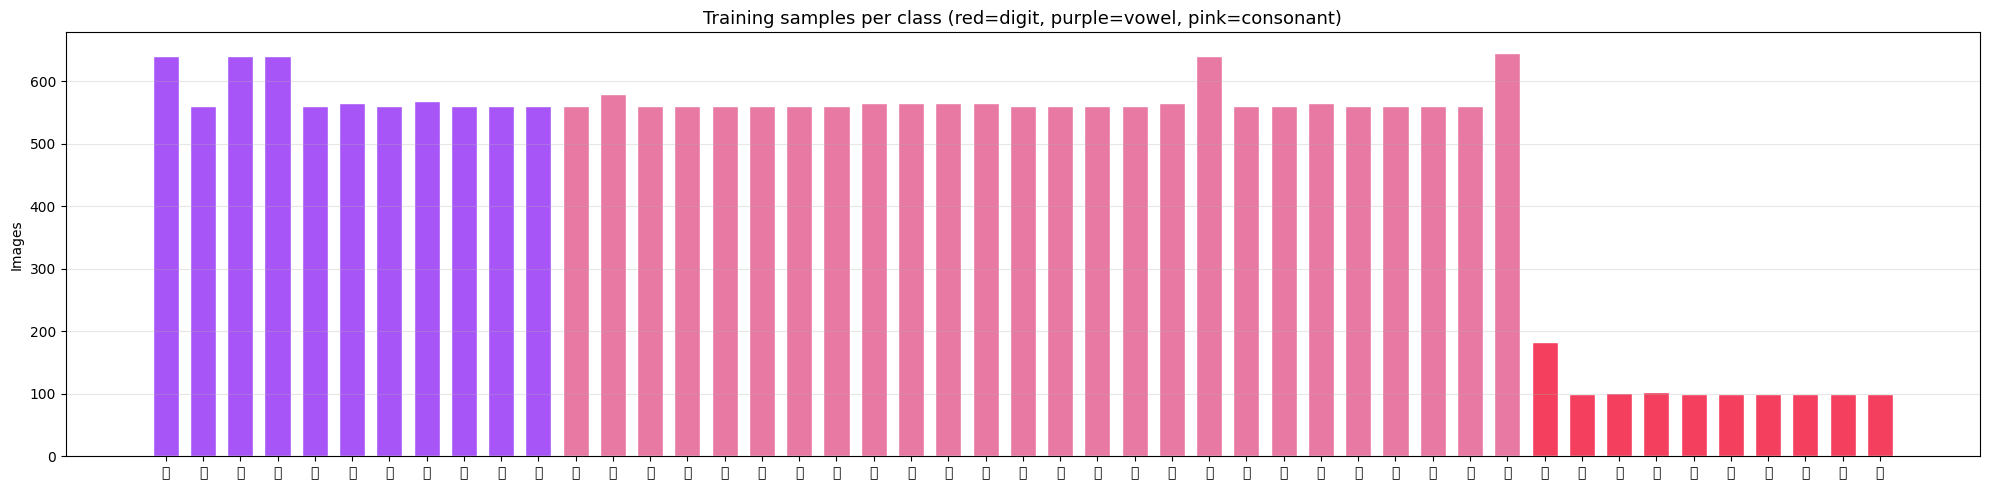

Total train images: 22283


In [13]:
train_dir = Path(f'{PROCESSED}/train')
class_counts = {}
for d in sorted(train_dir.iterdir()):
    if d.is_dir():
        class_counts[d.name] = len(list(d.glob('*.jpg')))

labels  = list(class_counts.keys())
counts  = list(class_counts.values())
colors  = ['#f43f5e' if k.startswith('digit') else
           '#a855f7' if LABEL_MAP.get(k,{}).get('type')=='vowel' else '#e879a3'
           for k in labels]

fig, ax = plt.subplots(figsize=(20, 5))
bars = ax.bar(range(len(labels)), counts, color=colors, width=0.7, edgecolor='white')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(
    [LABEL_MAP.get(l, {}).get('display', l) for l in labels],
    fontsize=10
)
ax.set_title('Training samples per class (red=digit, purple=vowel, pink=consonant)', fontsize=13)
ax.set_ylabel('Images')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()
print(f'Total train images: {sum(counts)}')

## 🔄 Step 3: Data Generators

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.08,
    zoom_range=0.12,
    horizontal_flip=False,   # sign language is laterally meaningful
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f'{PROCESSED}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    f'{PROCESSED}/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Classes detected: {len(train_gen.class_indices)}')
print(f'Train: {train_gen.samples} | Val: {val_gen.samples}')

# Save class_indices
with open(CI_OUT, 'w') as f:
    json.dump(train_gen.class_indices, f, indent=2)
print(f'✅ class_indices saved to {CI_OUT}')

Found 22283 images belonging to 47 classes.
Found 6221 images belonging to 47 classes.
Classes detected: 47
Train: 22283 | Val: 6221
✅ class_indices saved to ./class_indices.json


## 🖼️ Step 4: Sample Grid — All 47 Classes

C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\3435639451.py:20: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\3435639451.py:20: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\3435639451.py:20: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\3435639451.py:20: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\3435639451.py:20: UserWarning: Glyph 2440 (\N{BENGALI LETTER II}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\3435639451.py:20: UserWarning: Glyph 2441 (\N{BENGALI LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layou

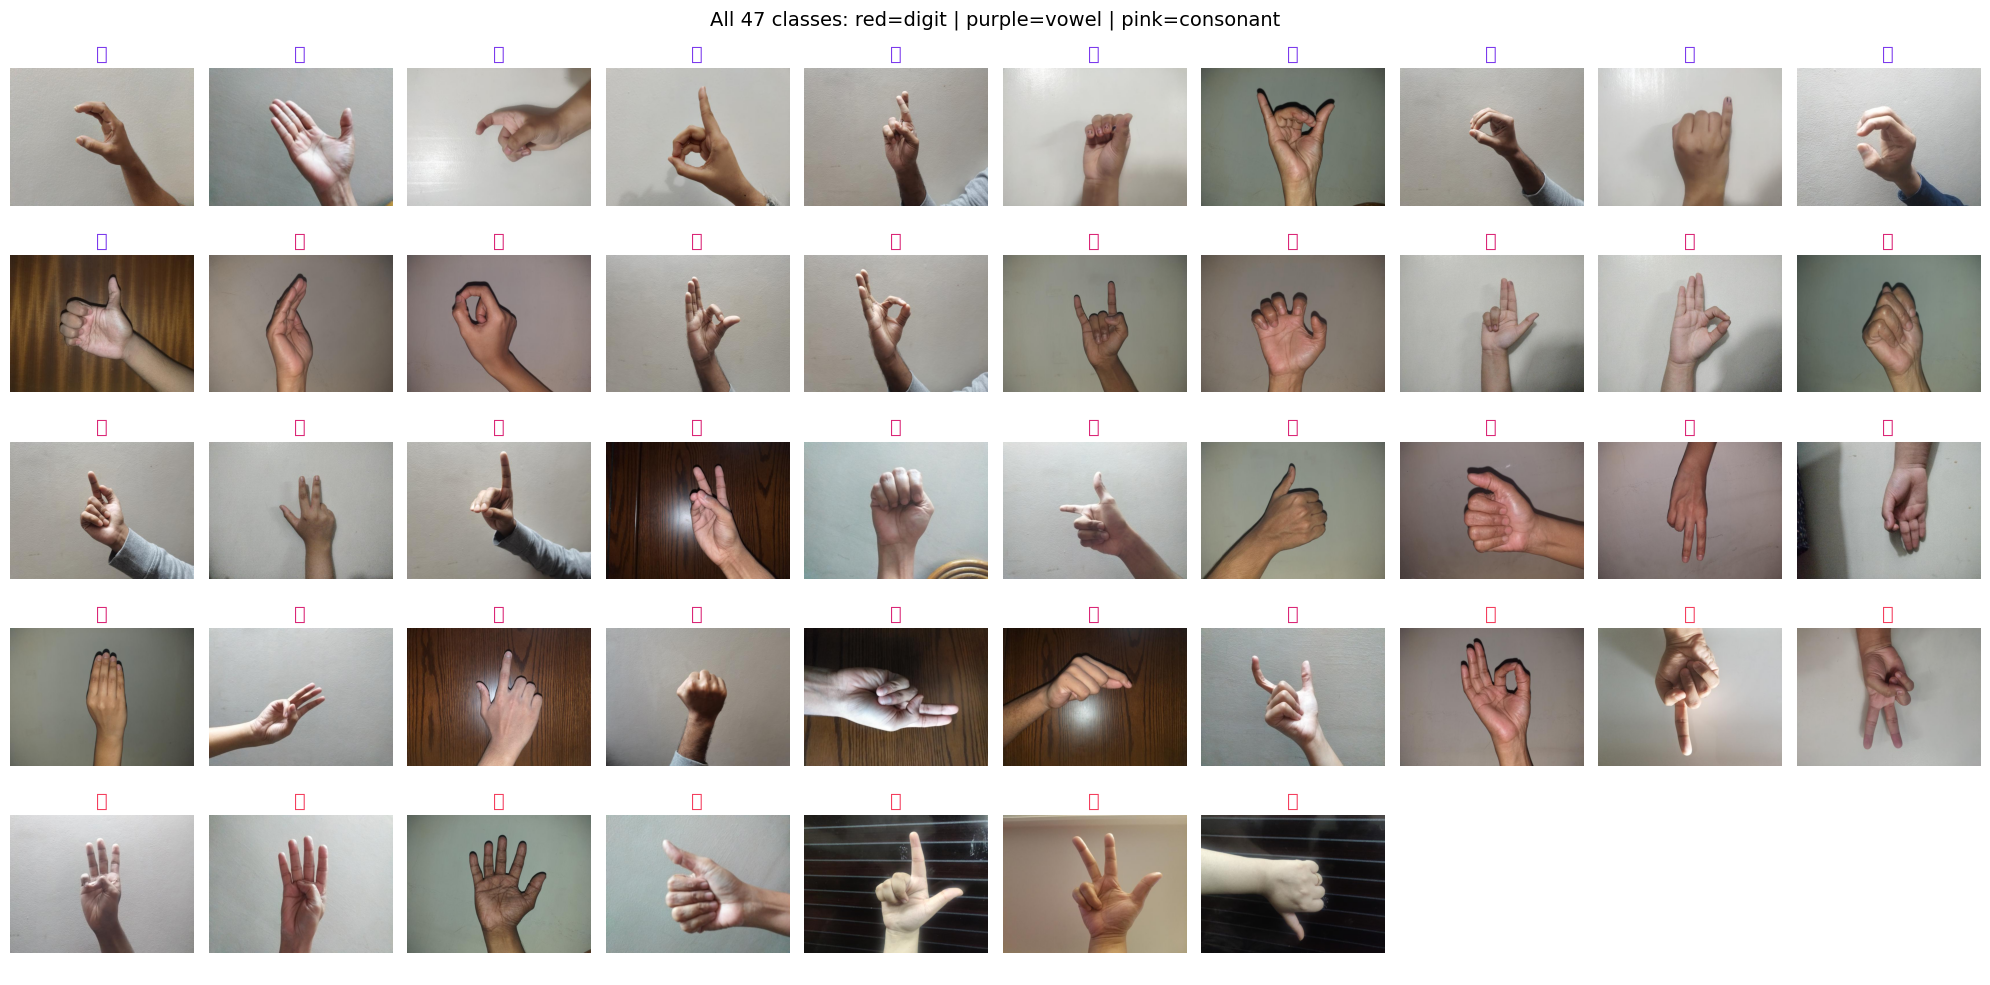

In [15]:
fig, axes = plt.subplots(5, 10, figsize=(20, 10))
axes = axes.flatten()

all_classes = sorted(Path(f'{PROCESSED}/train').iterdir())
for i, cls_dir in enumerate(all_classes[:50]):
    imgs = list(cls_dir.glob('*.jpg'))
    if not imgs: continue
    img = plt.imread(imgs[0])
    axes[i].imshow(img)
    label = LABEL_MAP.get(cls_dir.name, {}).get('display', cls_dir.name)
    ltype = LABEL_MAP.get(cls_dir.name, {}).get('type', '')
    color = '#f43f5e' if ltype == 'digit' else '#7c3aed' if ltype == 'vowel' else '#db2777'
    axes[i].set_title(label, fontsize=14, color=color, fontweight='bold')
    axes[i].axis('off')

for j in range(len(all_classes), 50):
    axes[j].axis('off')

fig.suptitle('All 47 classes: red=digit | purple=vowel | pink=consonant', fontsize=14)
plt.tight_layout()
plt.savefig('all_classes_sample.png', dpi=80)
plt.show()

## 🧠 Step 5: Build MobileNetV2 Model (47 classes)

In [16]:
def build_model(num_classes):
    base = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
    base.trainable = False

    inp = keras.Input(shape=(*IMG_SIZE, 3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.Dropout(0.45)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.35)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inp, out), base

model, base_model = build_model(NUM_CLASSES)

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
total     = sum(np.prod(w.shape) for w in model.weights)
print(f'Trainable: {trainable:,} / Total: {total:,}')
model.summary()

9406464/9406464 [==============================] - 21s 2us/step
Trainable: 801,839 / Total: 3,062,383
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 mobilenetv2_1.00_96 (Funct  (None, 3, 3, 1280)        2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_1 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dense_3 (Dense)       

## 🏋️ Step 6: Phase 1 — Train Head (base frozen)

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cbs = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1),
    keras.callbacks.ModelCheckpoint(MODEL_OUT, save_best_only=True, monitor='val_accuracy', verbose=1),
]

history1 = model.fit(train_gen, epochs=EPOCHS_FROZEN, validation_data=val_gen, callbacks=cbs)
print('\n✅ Phase 1 complete')

Epoch 1/5
2786/2786 [==============================] - ETA: 0s - loss: 2.0759 - accuracy: 0.4360
Epoch 1: val_accuracy improved from -inf to 0.66983, saving model to .\bangla_sign_model.h5
2786/2786 [==============================] - 221s 78ms/step - loss: 2.0759 - accuracy: 0.4360 - val_loss: 1.1149 - val_accuracy: 0.6698 - lr: 0.0010


C:\Users\adoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/5
2785/2786 [============================>.] - ETA: 0s - loss: 1.4368 - accuracy: 0.5852
Epoch 2: val_accuracy improved from 0.66983 to 0.73622, saving model to .\bangla_sign_model.h5
2786/2786 [==============================] - 111s 40ms/step - loss: 1.4366 - accuracy: 0.5852 - val_loss: 0.8863 - val_accuracy: 0.7362 - lr: 0.0010
Epoch 3/5
2785/2786 [============================>.] - ETA: 0s - loss: 1.2486 - accuracy: 0.6417
Epoch 3: val_accuracy improved from 0.73622 to 0.77560, saving model to .\bangla_sign_model.h5
2786/2786 [==============================] - 112s 40ms/step - loss: 1.2488 - accuracy: 0.6417 - val_loss: 0.7489 - val_accuracy: 0.7756 - lr: 0.0010
Epoch 4/5
2786/2786 [==============================] - ETA: 0s - loss: 1.1436 - accuracy: 0.6713
Epoch 4: val_accuracy improved from 0.77560 to 0.78010, saving model to .\bangla_sign_model.h5
2786/2786 [==============================] - 112s 40ms/step - loss: 1.1436 - accuracy: 0.6713 - val_loss: 0.7669 - val_accurac

## 🔓 Step 7: Phase 2 — Fine-tune Last 40 Base Layers

In [18]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(train_gen, epochs=EPOCHS_FINETUNE, validation_data=val_gen, callbacks=cbs)
print('\n✅ Phase 2 complete')

Epoch 1/5
2786/2786 [==============================] - ETA: 0s - loss: 1.0462 - accuracy: 0.6922
Epoch 1: val_accuracy improved from 0.78621 to 0.79280, saving model to .\bangla_sign_model.h5
2786/2786 [==============================] - 141s 49ms/step - loss: 1.0462 - accuracy: 0.6922 - val_loss: 0.6852 - val_accuracy: 0.7928 - lr: 1.0000e-05
Epoch 2/5
2785/2786 [============================>.] - ETA: 0s - loss: 0.9222 - accuracy: 0.7303
Epoch 2: val_accuracy did not improve from 0.79280
2786/2786 [==============================] - 146s 53ms/step - loss: 0.9224 - accuracy: 0.7302 - val_loss: 0.6874 - val_accuracy: 0.7878 - lr: 1.0000e-05
Epoch 3/5
2785/2786 [============================>.] - ETA: 0s - loss: 0.8515 - accuracy: 0.7496
Epoch 3: val_accuracy improved from 0.79280 to 0.82222, saving model to .\bangla_sign_model.h5
2786/2786 [==============================] - 162s 58ms/step - loss: 0.8516 - accuracy: 0.7496 - val_loss: 0.5804 - val_accuracy: 0.8222 - lr: 1.0000e-05
Epoch 4/5

## 📈 Step 8: Training Curves

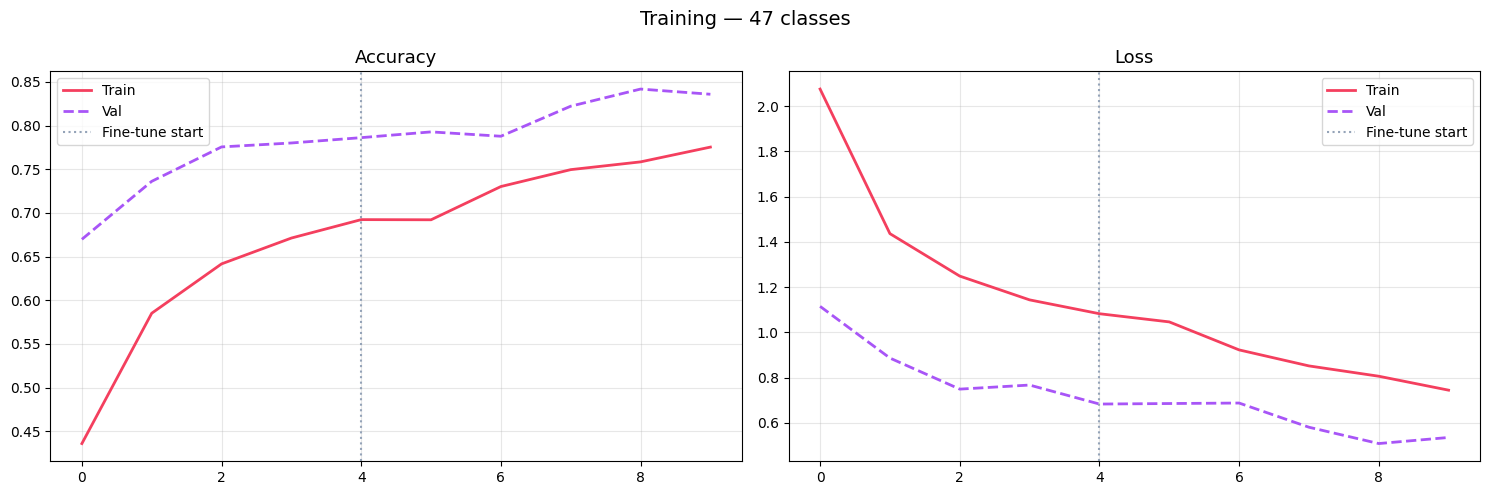

In [19]:
acc   = history1.history['accuracy']      + history2.history['accuracy']
val_a = history1.history['val_accuracy']  + history2.history['val_accuracy']
loss  = history1.history['loss']          + history2.history['loss']
val_l = history1.history['val_loss']      + history2.history['val_loss']
split = len(history1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for ax, y1, y2, title in [
    (ax1, acc, val_a, 'Accuracy'),
    (ax2, loss, val_l, 'Loss')
]:
    ax.plot(y1, label='Train', color='#f43f5e', linewidth=2)
    ax.plot(y2, label='Val',   color='#a855f7', linewidth=2, linestyle='--')
    ax.axvline(split-1, color='#94a3b8', linestyle=':', label='Fine-tune start')
    ax.set_title(title, fontsize=13); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'Training — {NUM_CLASSES} classes', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()

## 🎯 Step 9: Evaluation

In [20]:
val_gen.reset()
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

idx_to_class = {v: k for k, v in train_gen.class_indices.items()}
display_names = [LABEL_MAP.get(idx_to_class[i], {}).get('display', idx_to_class[i])
                 for i in range(NUM_CLASSES)]

print('\n📊 Classification Report:')
print(classification_report(y_true, y_pred, target_names=display_names))

val_loss, val_acc = model.evaluate(val_gen, verbose=0)
print(f'\n✅ Validation Accuracy: {val_acc*100:.2f}%')

778/778 [==============================] - 17s 21ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           অ       0.96      0.95      0.95       160
           আ       0.98      0.99      0.98       141
           ই       0.99      0.89      0.94       160
           ঈ       0.81      0.76      0.78       161
           উ       0.95      0.95      0.95       140
           ঊ       0.87      0.93      0.90       142
           ঋ       0.98      0.96      0.97       140
           এ       0.94      0.92      0.93       143
           ঐ       0.99      0.92      0.96       141
           ও       0.90      0.83      0.86       140
           ঔ       0.91      0.84      0.87       140
           ক       0.82      0.98      0.89       140
           খ       0.82      0.99      0.89       145
           গ       0.91      0.85      0.88       140
           ঘ       0.70      0.90      0.79       140
           ঙ       1.00      0.87      0.93       14

C:\Users\adoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\adoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Matplotlib currently does not support Bengali natively.
  fig.canvas.draw()
C:\Users\adoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2438 (\N{BENGALI LETTER AA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\adoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 2439 (\N{BENGALI LETTER I}) missing from font(s) Deja

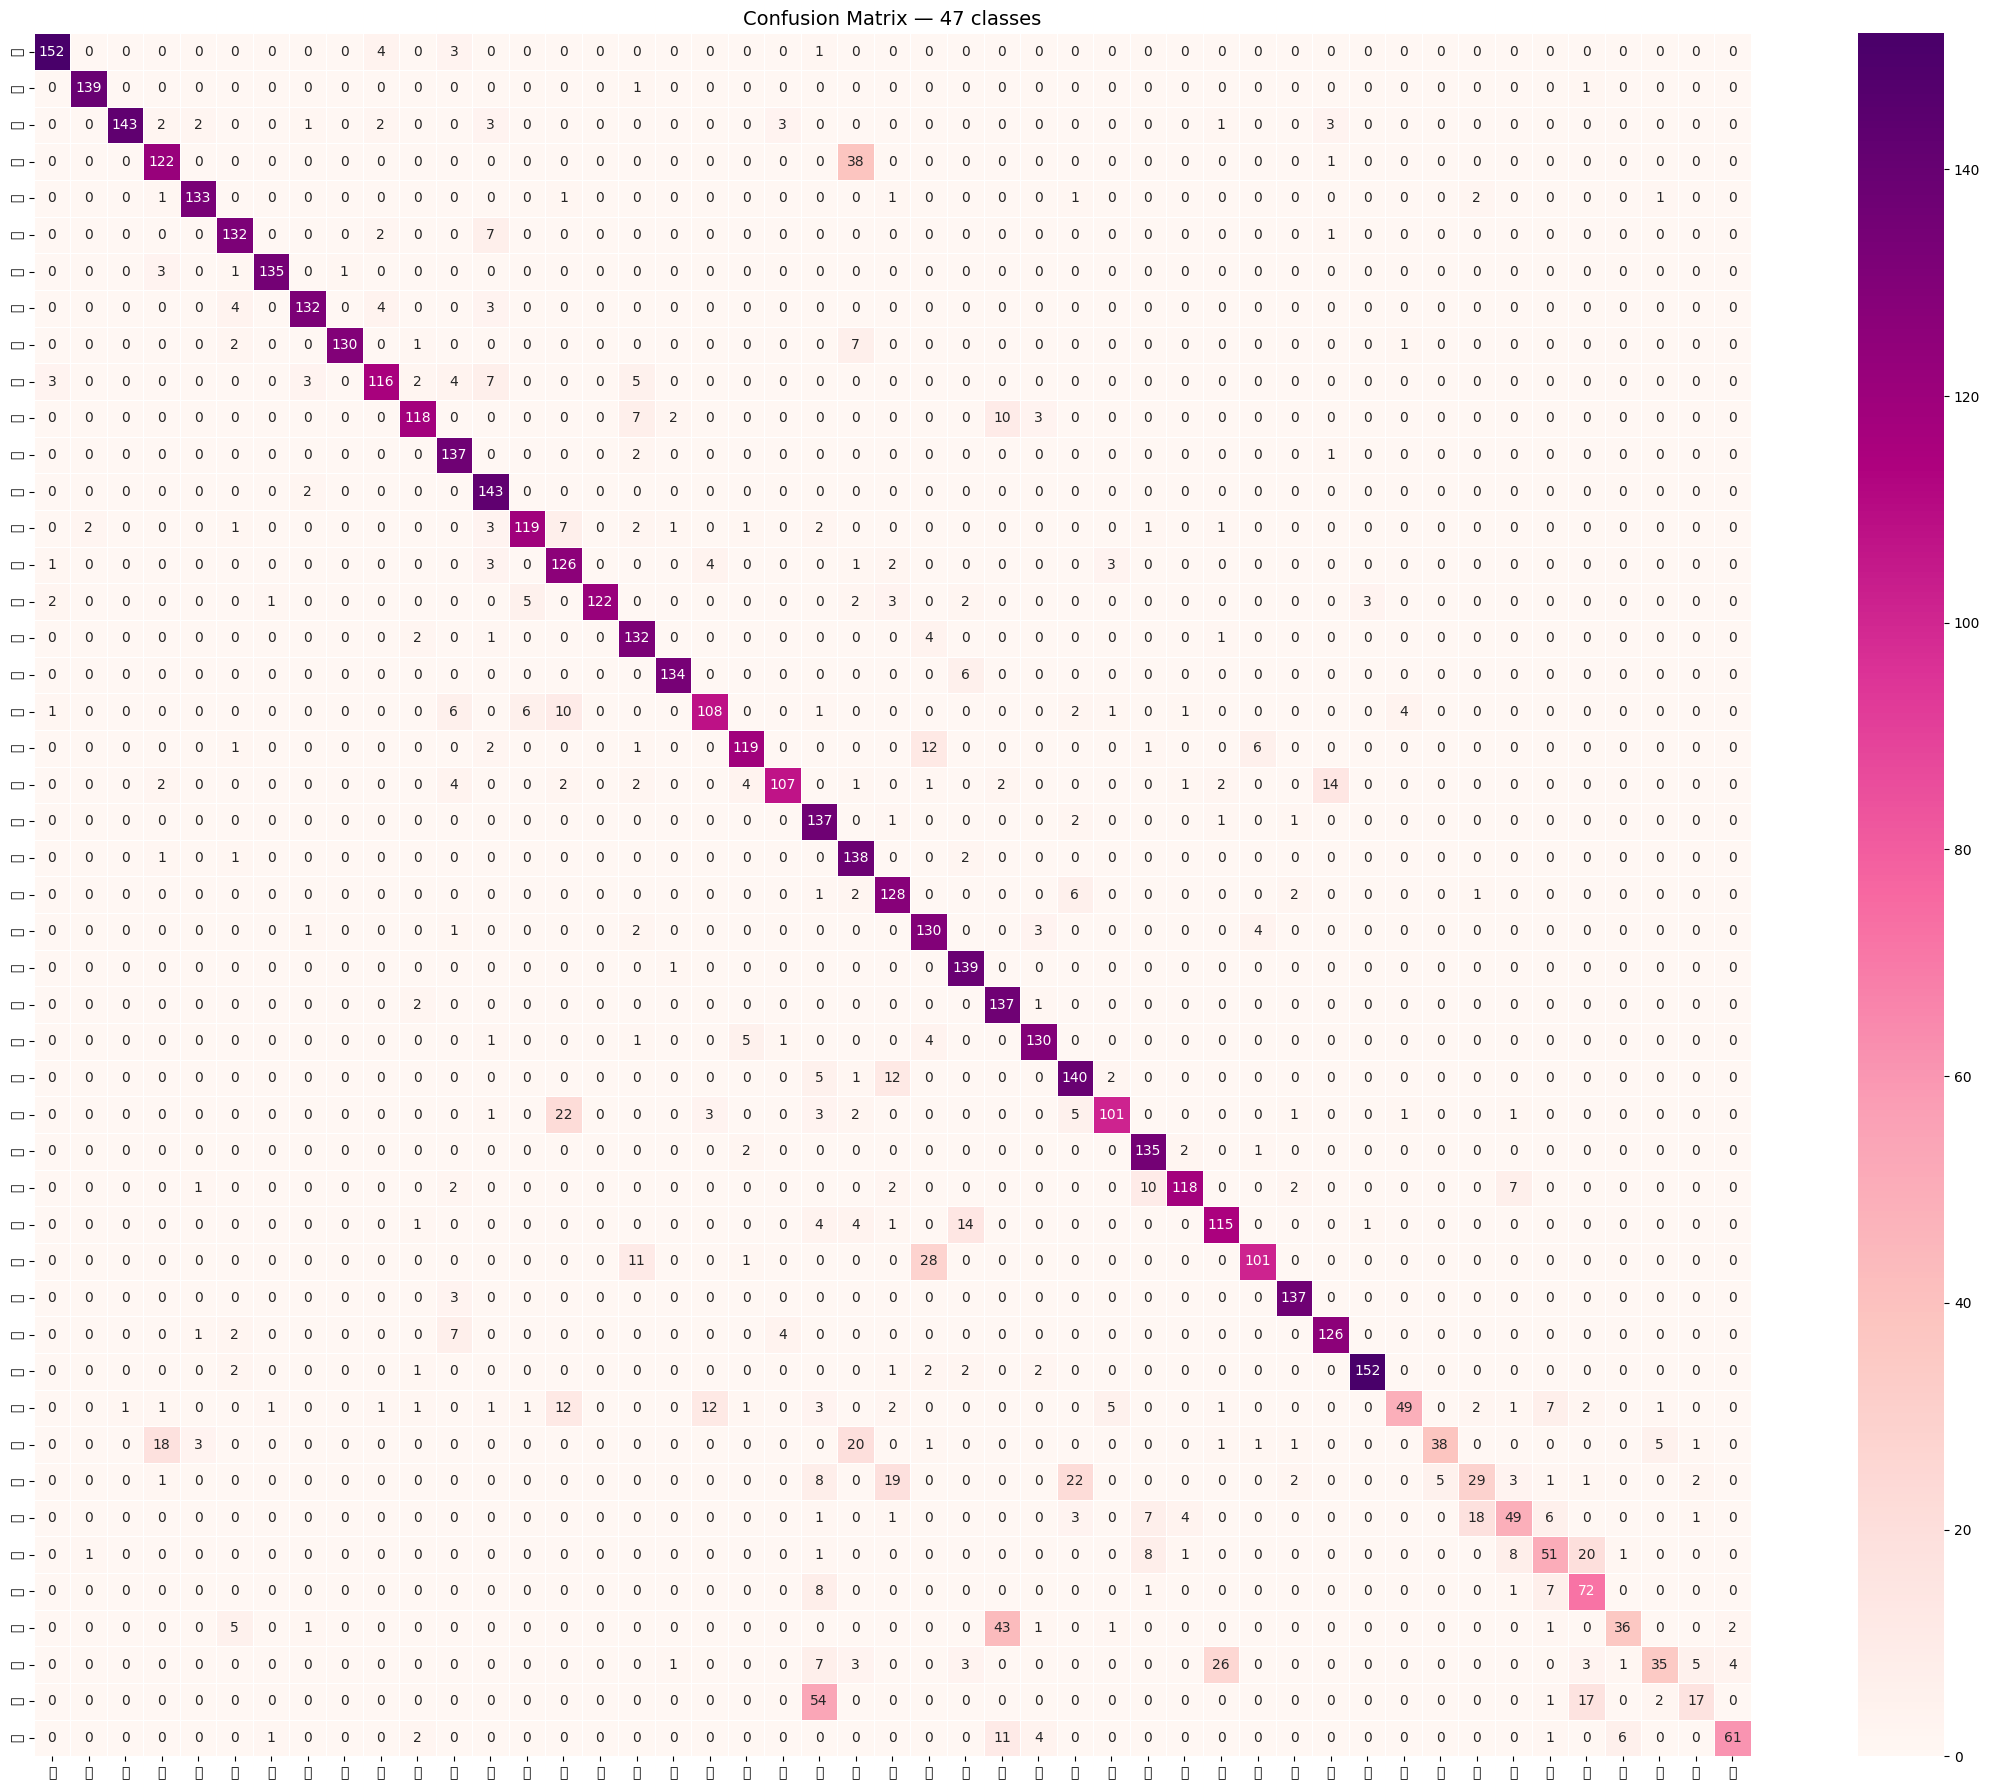

In [21]:
# Confusion matrix (47×47)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=display_names, yticklabels=display_names,
            linewidths=0.5, ax=ax)
ax.set_title(f'Confusion Matrix — {NUM_CLASSES} classes', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=80)
plt.show()

## 💾 Step 10: Export for Deployment

In [22]:
# Save model
model.save(MODEL_OUT)
print(f'✅ Model → {MODEL_OUT}')

# Copy to backend
shutil.copy(MODEL_OUT, '../backend/bangla_sign_model.h5')
shutil.copy(CI_OUT,    '../backend/class_indices.json')
print('✅ Copied to backend/')

C:\Users\adoc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


✅ Model → ./bangla_sign_model.h5
✅ Copied to backend/


## 🔍 Step 11: Quick Inference Test

C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\4015336482.py:20: UserWarning: Glyph 2460 (\N{BENGALI LETTER JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\4015336482.py:20: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\4015336482.py:20: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\adoc\AppData\Local\Temp\ipykernel_15600\4015336482.py:20: UserWarning: Glyph 2437 (\N{BENGALI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


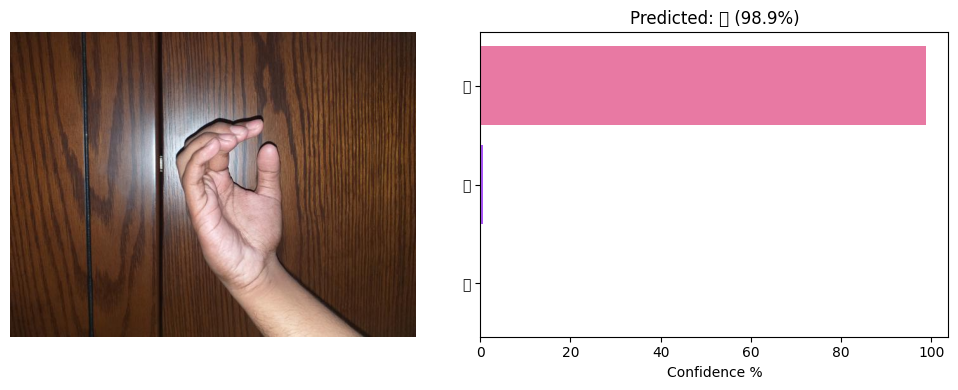

('অ', 98.85544180870056)

In [23]:
from tensorflow.keras.preprocessing import image as kimg

def predict_sign(img_path):
    idx_to_cls = {v: k for k, v in train_gen.class_indices.items()}
    img = kimg.load_img(img_path, target_size=IMG_SIZE)
    arr = np.expand_dims(kimg.img_to_array(img) / 255.0, 0)
    preds = model.predict(arr, verbose=0)[0]
    top3  = np.argsort(preds)[::-1][:3]

    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))
    ax_img.imshow(kimg.load_img(img_path))
    ax_img.axis('off')

    top_labels = [LABEL_MAP.get(idx_to_cls[i], {}).get('display', idx_to_cls[i]) for i in top3]
    top_scores = [preds[i] * 100 for i in top3]
    ax_bar.barh(top_labels[::-1], top_scores[::-1], color=['#f43f5e','#a855f7','#e879a3'])
    ax_bar.set_xlabel('Confidence %')
    ax_bar.set_title(f'Predicted: {top_labels[0]} ({top_scores[0]:.1f}%)')

    plt.tight_layout()
    plt.show()
    return top_labels[0], top_scores[0]

# Pick a random val image
sample = list(Path(f'{PROCESSED}/val').rglob('*.jpg'))[0]
predict_sign(sample)